In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## Corrida 7:

In [2]:
df7 = pd.read_csv("experimental_data/corrida7.csv", sep="\t")

print(df7.head())

   Posição angular ( graus )  Intensidade rel. ( % )
0                          0                       1
1                          0                   17155
2                          0                   17167
3                          0                   17170
4                          0                   17226


In [3]:
df7["Posição angular ( graus )"] = df7["Posição angular ( graus )"] / 1000

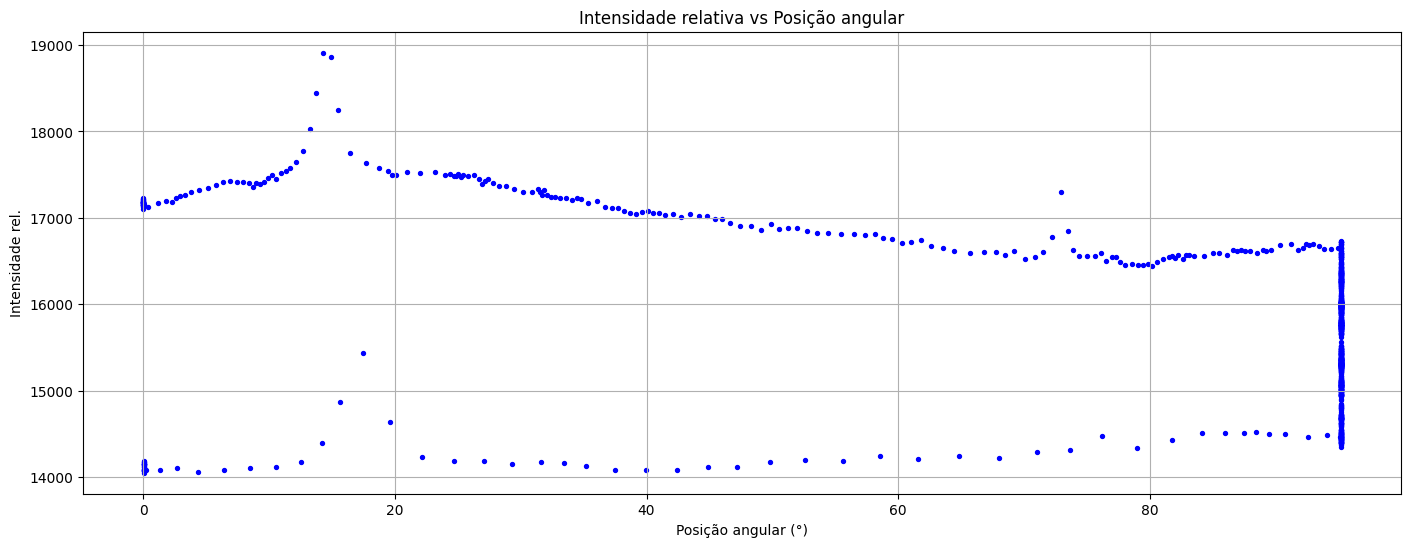

In [4]:
#mudar tamanho da figura
plt.figure(figsize=(17, 6))
plt.scatter(df7["Posição angular ( graus )"][1:], df7["Intensidade rel. ( % )"][1:], color="blue", label="Dados experimentais",marker='o',s=8)
plt.xlabel("Posição angular (°)")
plt.ylabel("Intensidade rel.")
plt.title("Intensidade relativa vs Posição angular")
plt.grid()
plt.show()  

In [5]:
df7 = df7[df7['Posição angular ( graus )'] <= 61]
df7 = df7[df7['Intensidade rel. ( % )'] >= 16000]

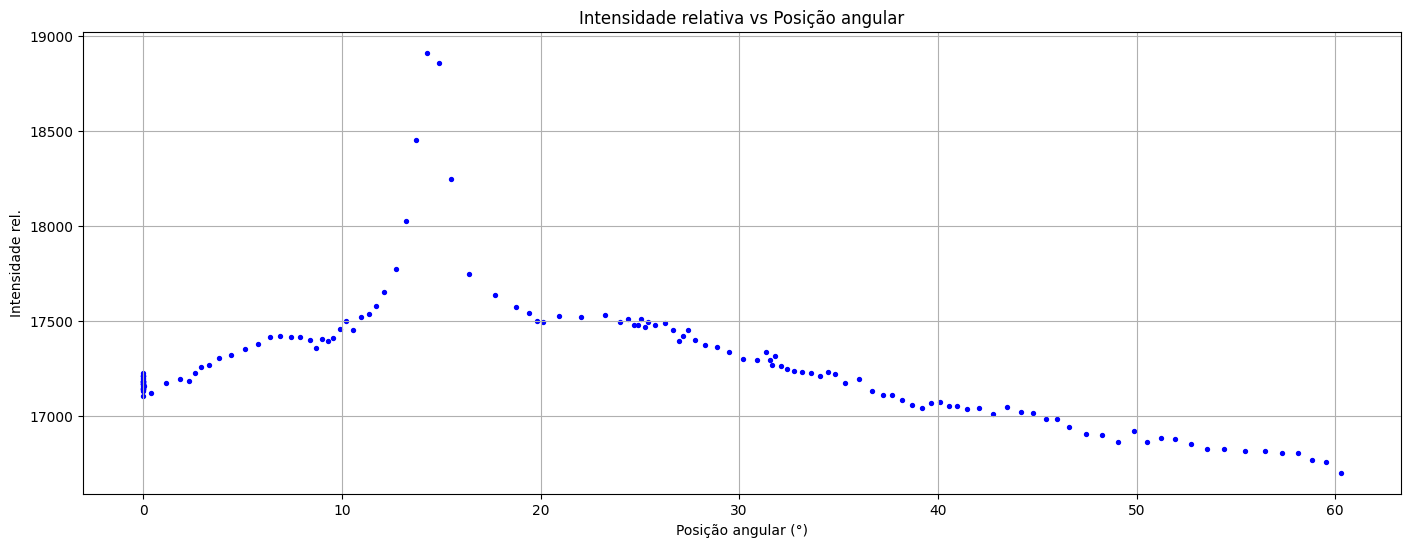

In [6]:
#mudar tamanho da figura
plt.figure(figsize=(17, 6))
plt.scatter(df7["Posição angular ( graus )"][1:], df7["Intensidade rel. ( % )"][1:], color="blue", label="Dados experimentais",marker='o',s=8)
plt.xlabel("Posição angular (°)")
plt.ylabel("Intensidade rel.")
plt.title("Intensidade relativa vs Posição angular")
plt.grid()
plt.show()  

In [7]:
df7 = df7[df7['Posição angular ( graus )'] >= 10]

In [8]:
theta = df7["Posição angular ( graus )"]

theta_rad = np.deg2rad(theta)

df7["Posição angular ( graus )"] = theta_rad

In [9]:
A = 13900
B = 1.689
n = ( ( 2*np.sin(1.3439-theta_rad)/(3**0.5) + (1/2) ) ** 2 + (3/4) ) ** 0.5

In [10]:
lambida = ( A / (n - B) ) ** 0.5

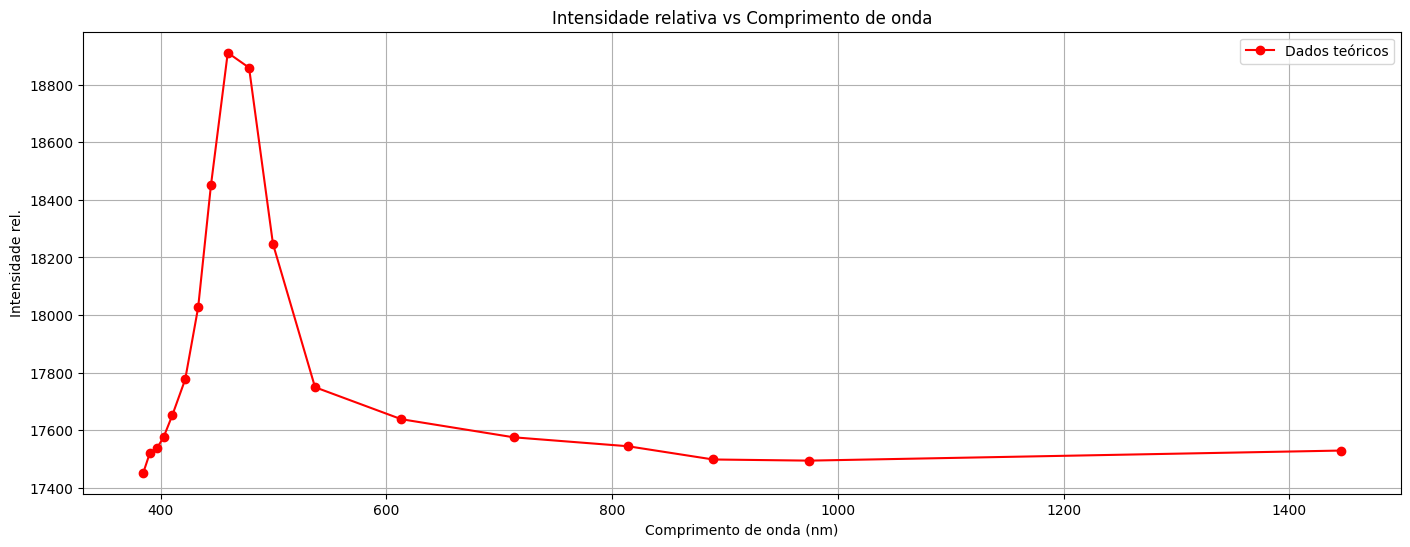

In [11]:
plt.figure(figsize=(17, 6))
plt.plot(lambida[1:-3], df7["Intensidade rel. ( % )"][1:-3], color="red", label="Dados teóricos",marker='o')#,marksize=8)
plt.xlabel("Comprimento de onda (nm)")
plt.ylabel("Intensidade rel.")
plt.title("Intensidade relativa vs Comprimento de onda")
plt.grid()
plt.legend()
plt.show()

## Algorítimo:

### 1. Ler:

In [20]:
corrida7_bruto = pd.read_csv('experimental_data/corrida7.txt', sep='\t')
display(corrida7_bruto.head(25))

,Posição_Angular(graus),Intensidade_rel_(%)
0,"0,000","0,001"
1,"0,000","17,155"
2,"0,000","17,167"
3,"0,000","17,170"
4,"0,000","17,226"
5,"0,000","17,180"
6,"0,000","17,210"
7,"0,000","17,211"
8,"0,000","17,179"
9,"0,000","17,182"


In [21]:
# Informações gerais
print(f"Corrida - Dados brutos:\n{corrida7_bruto.info()}")

# Tipos das colunas
print(f"Tipos das colunas:\n{corrida7_bruto.dtypes}")

# Estatísticas descritivas
print(f"Estatísticas descritivas:\n{corrida7_bruto.describe()}")

# Quantidade de valores nulos
print(f"Quantidade de valores nulos:\n{corrida7_bruto.isnull().sum()}")

# Dimensão do dataframe
print(f"Dimensão do dataframe:\n{corrida7_bruto.shape}")

# Nomes das colunas
print(f"Nomes das colunas:\n{corrida7_bruto.columns}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 2 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Posição_Angular(graus)  1200 non-null   object
 1   Intensidade_rel_(%)     1200 non-null   object
dtypes: object(2)
memory usage: 18.9+ KB
Corrida - Dados brutos:
None
Tipos das colunas:
Posição_Angular(graus)    object
Intensidade_rel_(%)       object
dtype: object
Estatísticas descritivas:
       Posição_Angular(graus) Intensidade_rel_(%)
count                    1200                1200
unique                    254                 923
top                    95,146              15,301
freq                      258                   5
Quantidade de valores nulos:
Posição_Angular(graus)    0
Intensidade_rel_(%)       0
dtype: int64
Dimensão do dataframe:
(1200, 2)
Nomes das colunas:
Index(['Posição_Angular(graus)', 'Intensidade_rel_(%)'], dtype='object')


### 2. Limpar:

In [14]:
corrida7_limpo = corrida7_bruto.copy()
corrida7_limpo['Posição_Angular(graus)'] = corrida7_bruto['Posição_Angular(graus)'].str.replace(",", ".", case=False, regex=False)
corrida7_limpo['Intensidade_rel_(%)'] = corrida7_bruto['Intensidade_rel_(%)'].str.replace(",", ".", case=False, regex=False)

In [15]:
print(corrida7_limpo.dtypes)

Posição_Angular(graus)    object
Intensidade_rel_(%)       object
dtype: object


In [16]:
corrida7_limpo['Posição_Angular(graus)'] = pd.to_numeric(corrida7_limpo['Posição_Angular(graus)'])
corrida7_limpo['Intensidade_rel_(%)'] = pd.to_numeric(corrida7_limpo['Intensidade_rel_(%)'])

In [17]:
print(corrida7_limpo.dtypes)

Posição_Angular(graus)    float64
Intensidade_rel_(%)       float64
dtype: object


### 3. Visualizar:

In [18]:
def visualizar_dados(corrida):
    plt.figure(figsize=(17, 6))
    plt.scatter(corrida["Posição_Angular(graus)"], corrida["Intensidade_rel_(%)"], color="blue", label="Dados experimentais",marker='o',s=8)
    plt.xlabel("Posição angular (°)")
    plt.ylabel("Intensidade rel.")
    plt.title("Intensidade relativa vs Posição angular")
    plt.grid()
    plt.show()
    return None

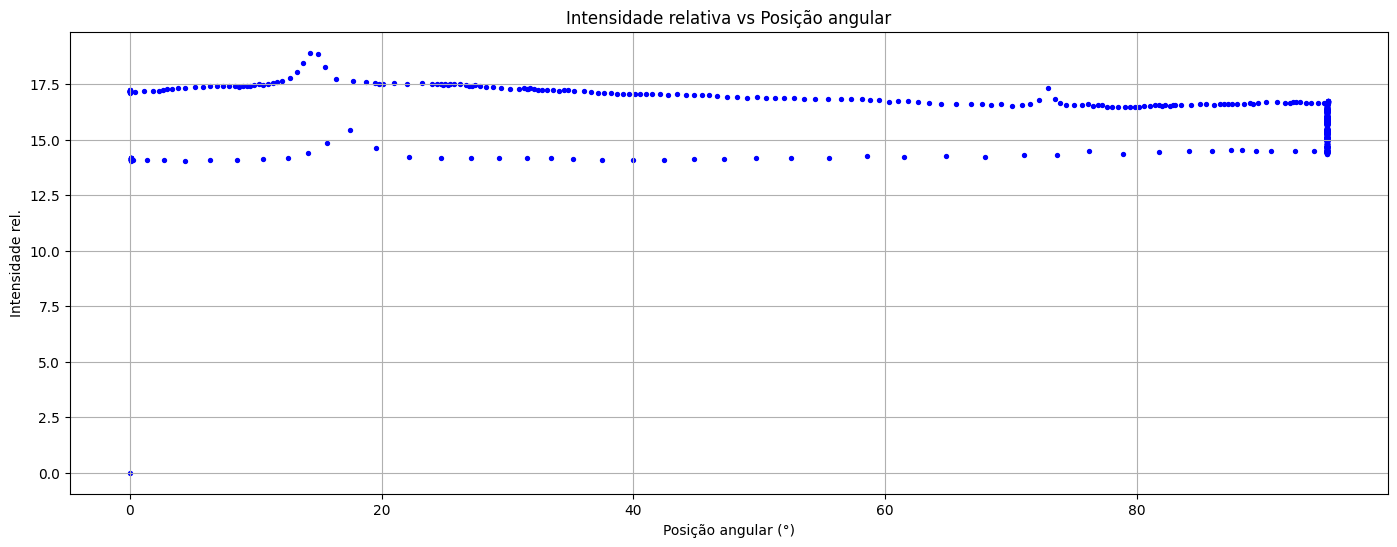

In [19]:
visualizar_dados(corrida7_limpo)

## Corrida 8: